# Matching and comparison of the database with external sources

In [1]:
%load_ext autoreload
%autoreload 2

In [57]:
import pandas as pd
import ast
import geopandas as gpd
from copy import deepcopy as dc
from matplotlib.ticker import LogLocator, FuncFormatter
import matplotlib.pyplot as plt

import os
import sys
current_dir = os.getcwd()
project_root = os.path.dirname(current_dir)
sys.path.append(project_root)

from src.data import *
from src.post_process_functions import *
from src.hazard_def import *
from src.external_comparaison import *
from src.data_format import format_output, LIST_COLS

path_save_fig = DATA_FIGURE / "validation_external_sources"
#sys.path.append('/home/lhasbini/como_school/como_project4/src/')

In [58]:
# 200 reports 
# res_name_llm = "post_processed_monty_200rep_meta-llama_llama-4-scout-17b-16e-instruct_v190925"
# res_name_llm = "filtered_post_processed_geocoded_all_appeals_longest_1-717_meta-llama_llama-4-scout-17b-16e-instruct_v121225"
# res_name_llm = "merged_subtypespost_processed_all_appeals_longest_1-717_meta-llama_llama-4-scout-17b-16e-instruct_v121225_geo_v171225"
res_name_llm = "merged_subtypespost_processed_all_appeals_longest_1-717_meta-llama_llama-4-scout-17b-16e-instruct_v121225_v120226_geo"
cols = [
    "appealCode", 
    "reportDate",
    "impactSubtype", 
    "impactValue", 
    "impactValueMin", 
    "impactValueMax", 
    "impactValuePrecision", 
    "impactUnit",
    "valueAnnotation", 
    "location", 
    "locationAnnotation", 
    "locationPolygon",
    "locationLowestAdmin",
    "country_robust_iso3",
    "hazards", 
    'startYear', 
    'startMonth', 
    'startDay', 
    'endYear', 
    'endMonth', 
    'endDay'
]
# df_llm_all_geo = pd.read_parquet(DATA_OUT_PROC/(res_name_llm+'.parquet'), columns=cols)
df_llm_all = pd.read_csv(os.path.join(DATA_OUT_PROC, res_name_llm+'.csv'), encoding='utf-8')
df_llm_all = format_output(df_llm_all, list_cols=LIST_COLS+["country_robust_iso3"])
# df_llm_all_geo = gpd.read_file(os.path.join(DATA_OUT_PROC, res_name_llm+'_geo_v191225.gpkg'))

# col_to_list = ["location", "country", "country_kw", "country_iso3", "hazards"]
# df_llm_all[col_to_list] = df_llm_all[col_to_list].map(lambda x: listify_strings(x))

# col_to_list = ["location", "locationPolygon", "iso3_code", "hazards"]
# df_llm_all_geo[col_to_list] = df_llm_all_geo[col_to_list].map(lambda x: listify_strings(x))

In [69]:
col_to_list = ["location", "hazards", "country_robust_iso3"]
df_llm_all[col_to_list] = df_llm_all[col_to_list].map(lambda x: listify_strings(x))

In [71]:
df_llm_all_geo_grp = clean_group(df_llm_all, ADM_min=0)

In [10]:
# Import data from other sources
df_ifrc_go = open_clean_ifrc_go()
df_ifrc_monty = open_clean_ifrc_monty(df_ifrc_go)
df_em_dat = open_emdat()

df_external_source = {}
df_external_source["ifrc_go"] = df_ifrc_go
df_external_source["ifrc_monty"] = df_ifrc_monty
df_external_source["emdat"] = df_em_dat

In [18]:
print("Number of unique appealCode from the IFRCGO API : ", df_external_source["ifrc_go"]["appealCode"].nunique())
print("Number of unique common appealCode with the LLM-extracted reports : ", df_llm_all_geo_grp.loc[df_llm_all_geo_grp["appealCode"].isin(df_external_source["ifrc_go"]["appealCode"].unique())]["appealCode"].nunique())

Number of unique appealCode from the IFRCGO API :  2728
Number of unique common appealCode with the LLM-extracted reports :  523


In [73]:
df_llm_all_geo_grp_linked = {}

# MATCHING WITH IFRC MONTY 
df_ifrc_monty_subset = df_ifrc_monty[["appealCode", "impact_type", "impact_value", "impact_category"]]
df_llm_all_geo_grp_linked["ifrc_monty"] = df_llm_all_geo_grp.merge(df_ifrc_monty_subset, left_on=["appealCode", "impactSubtype"], right_on=["appealCode", "impact_type"])

# MATCHING WITH IFRC GO
df_llm_all_geo_grp_linked["ifrc_go"] = df_llm_all_geo_grp.merge(df_ifrc_go, on=["appealCode"])

# MATCHING WITH EMDAT
months = 3
date_diff_th = datetime.timedelta(days=months*30)
df_llm_all_geo_linked, df_llm_em_dat = matching_emdat(df_llm_all_geo_grp, df_em_dat, date_diff_th, "date_diff_start", country_field='country_robust_iso3')
df_llm_all_geo_grp_linked["emdat"] = df_llm_all_geo_linked

c:\Users\lhasbini\ownCloud\Documents\Thèse\programs\como_project4\como_project4\src\external_comparaison.py:39: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.copy()


In [75]:
print("Number of unique appealCode from the IFRCGO API : ", df_external_source["emdat"]["DisNo."].nunique())

Number of unique appealCode from the IFRCGO API :  14935


# Global plots

Need to plot informations about the raw dataset, such as : 
- Map with the number of event per country --> Need to filter over the same period 
- Total number of affected people (per year per country ?)
- % of reports for which we have information about each Impact Category (before matching with the ones extracted with LLM)

### Plot of % of reports with impact information 

In [84]:
df_external_source["ifrc_go"]["disaster_start_date"] = pd.to_datetime(df_external_source["ifrc_go"]["disaster_start_date"],
    errors='coerce')

In [85]:
nb_report_with_impact = {}
perc_report_with_impact = {}

In [86]:
external_source = "ifrc_go"

nb_report_with_impact[external_source] = []
perc_report_with_impact[external_source] = []

df_impact_ext = df_external_source[external_source]

for impactSubtype in mapping_impact_type.keys() : 
    col = mapping_impact_type[impactSubtype]['ifrc_go']
    if col is None :
        nb_report_with_impact[external_source].append(0)
        perc_report_with_impact[external_source].append(0)
        continue
    n = len(df_impact_ext.dropna(subset=impactSubtype))
    nb_report_with_impact[external_source].append(n)
    perc_report_with_impact[external_source].append(100*n/len(df_impact_ext))


In [87]:
external_source = "emdat"

nb_report_with_impact[external_source] = []
perc_report_with_impact[external_source] = []

df_impact_ext = df_external_source[external_source]

for impactSubtype in mapping_impact_type.keys() : 
    col = mapping_impact_type[impactSubtype]['emdat']
    if col is None :
        nb_report_with_impact[external_source].append(0)
        perc_report_with_impact[external_source].append(0)
        continue
    n = len(df_impact_ext.dropna(subset=col))
    nb_report_with_impact[external_source].append(n)
    perc_report_with_impact[external_source].append(100*n/len(df_impact_ext))


In [88]:
nb_report_with_impact_llm = []
perc_report_with_impact_llm = []

for impactSubtype in mapping_impact_type.keys() : 
    df_impact_ext = df_llm_all_geo_grp.loc[df_llm_all_geo_grp["impactSubtype"]==impactSubtype]
    n = df_impact_ext.dropna(subset="impactValue_final")["appealCode"].nunique()
    nb_report_with_impact_llm.append(n)
    perc_report_with_impact_llm.append(100*n/df_llm_all_geo_grp["appealCode"].nunique())


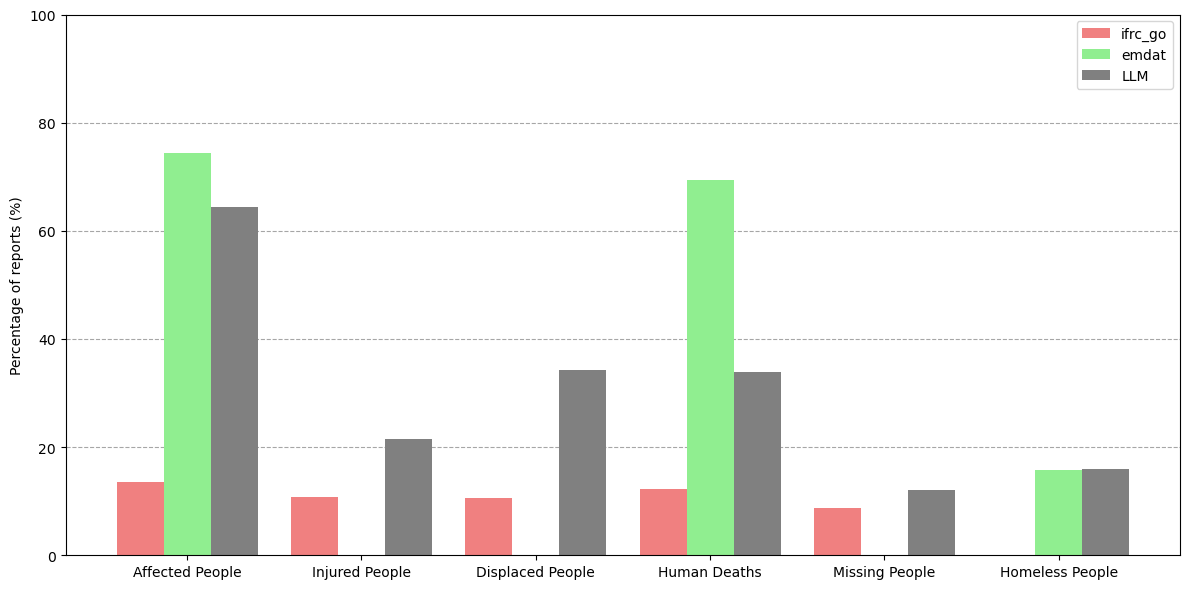

In [89]:
x = np.arange(len(mapping_impact_type.keys()))  # positions for bars
width = 0.27  # bar width

fig, ax = plt.subplots(figsize=(12,6))

# Define colors like in your previous example
colors = {}
colors["ifrc_monty"] = ["skyblue", "dodgerblue"]      # all / perfect match
colors["emdat"] = ["lightgreen", "green"]       # all / perfect match
colors["ifrc_go"] = ["lightcoral", "brown"]

for i, external_source in enumerate(perc_report_with_impact.keys()) : 
    # IFRC bars
    ax.bar(x + (i-1)*width, perc_report_with_impact[external_source], width, label=external_source, color=colors[external_source][0])

ax.bar(x + width, perc_report_with_impact_llm, width, label="LLM", color="grey")
# Labels
ax.set_xticks(x)
ax.set_xticklabels(mapping_impact_type.keys())
# ax.set_xticklabels(mapping_impact_type.keys(), rotation=45, ha="right")
ax.set_ylabel(r"Percentage of reports (%)")
# ax.set_title(r"Percentage of events with impact value")
ax.legend()

for y in [20, 40, 60, 80]:
    ax.axhline(y=y, color='gray', linestyle='--', linewidth=0.8, alpha=0.7, zorder=0)

ax.set_ylim(0, 100)

plt.tight_layout()
# fig.savefig(path_save_fig / f"percentage_events_quanti_impact.png", 
#             transparent=True, bbox_inches='tight', dpi=300)
# fig.savefig(path_save_fig / f"percentage_events_quanti_impact.svg", 
#             format="svg", transparent=True, bbox_inches='tight', dpi=300)
# fig.savefig(path_save_fig / f"percentage_events_quanti_impact.pdf", 
#             format="pdf", transparent=True, bbox_inches='tight', dpi=300)
plt.show()

## Bar Plot after event matching

In [101]:
nb_matched = {}
nb_exact_match = {}
nb_no_match = {}
nb_no_external_impact = {}
df_matched_with_impact = {}

tolerance = 0.10

In [121]:
# Number mapped and nb with exact matching 
external_source = "ifrc_monty"
nb_matched[external_source] = []
nb_exact_match[external_source] = []
df_matched_with_impact[external_source] = pd.DataFrame()

# Compute differences
df_llm_all_geo_grp_linked[external_source]["abs_diff"] = abs(
    df_llm_all_geo_grp_linked[external_source]["impact_value"]
    - df_llm_all_geo_grp_linked[external_source]["impactValue_final"]
)

# Compute relative difference (avoid division by zero)
df_llm_all_geo_grp_linked[external_source]["rel_diff"] = (
    df_llm_all_geo_grp_linked[external_source]["abs_diff"]
    / df_llm_all_geo_grp_linked[external_source]["impact_value"].replace(0, np.nan)
)

# Mark rows as "match" if within tolerance
df_llm_all_geo_grp_linked[external_source]["match"] = df_llm_all_geo_grp_linked[external_source]["rel_diff"] <= tolerance

for impactSubtype in mapping_impact_type.keys() : 
    col = mapping_impact_type[impactSubtype]['ifrc_monty']
    if col is None :
        nb_matched[external_source].append(0)
        nb_exact_match[external_source].append(0)
        continue

    df_matched = df_llm_all_geo_grp_linked[external_source].loc[
        df_llm_all_geo_grp_linked[external_source]["impactSubtype"] == impactSubtype
    ]

    df_matched_with_impact[external_source] = pd.concat(
        [df_matched_with_impact[external_source], df_matched],
        axis=0,
        ignore_index=True,
    )

    nb_matched[external_source].append(df_matched["appealCode"].nunique())
    nb_exact_match[external_source].append(df_matched.loc[df_matched["match"]]["appealCode"].nunique())

In [122]:
# Number mapped and nb with exact matching 
external_source = "ifrc_go"
nb_matched[external_source] = []
nb_exact_match[external_source] = []
nb_no_external_impact[external_source] = []
df_matched_with_impact[external_source] = pd.DataFrame()

for impactSubtype in mapping_impact_type.keys() : 
    col = mapping_impact_type[impactSubtype]['ifrc_go']
    if col is None :
        nb_matched[external_source].append(0)
        nb_exact_match[external_source].append(0)
        nb_no_external_impact[external_source].append(0)
        continue

    df_matched = df_llm_all_geo_grp_linked[external_source].loc[df_llm_all_geo_grp_linked[external_source]["impactSubtype"] == impactSubtype]
    n_before = len(df_matched)
    df_matched = df_matched.dropna(subset=[impactSubtype])
    n_after = len(df_matched)

    # Compute differences safely
    df_matched["abs_diff"] = abs(df_matched["impactValue"] - df_matched[impactSubtype])

    df_matched["rel_diff"] = df_matched["abs_diff"] / (
        (abs(df_matched["impactValue"]) + abs(df_matched[impactSubtype])) / 2
    ).replace(0, np.nan)

    # Match if relative difference <= tolerance
    df_matched["match"] = df_matched["rel_diff"] <= tolerance
    df_matched_with_impact[external_source] = pd.concat(
        [df_matched_with_impact[external_source], df_matched],
        axis=0,
        ignore_index=True,
    )
    
    nb_no_external_impact[external_source].append(n_before-n_after)
    nb_matched[external_source].append(df_matched["appealCode"].nunique())
    nb_exact_match[external_source].append(df_matched.loc[df_matched["match"]]["appealCode"].nunique())

In [123]:
# Number mapped and nb with exact matching 
external_source = "emdat"
nb_matched[external_source] = []
nb_exact_match[external_source] = []
nb_no_external_impact[external_source] = []
df_matched_with_impact[external_source] = pd.DataFrame()

for impactSubtype in mapping_impact_type.keys() : 
    emdat_col = mapping_impact_type[impactSubtype][external_source]
    if emdat_col is None :
        nb_matched[external_source].append(0)
        nb_exact_match[external_source].append(0)
        nb_no_external_impact[external_source].append(0)
        continue

    df_matched = df_llm_all_geo_grp_linked[external_source].loc[df_llm_all_geo_grp_linked[external_source]["impactSubtype"] == impactSubtype]
    n_before = len(df_matched)
    # print(n_before, df_matched["appealCode"].nunique())
    df_matched = df_matched.dropna(subset=[mapping_impact_type[impactSubtype][external_source]])
    n_after = len(df_matched)
    # print(emdat_col, n_before, n_after, df_matched["appealCode"].nunique())

    # Compute differences safely
    df_matched["abs_diff"] = abs(df_matched["impactValue"] - df_matched[mapping_impact_type[impactSubtype][external_source]])

    df_matched["rel_diff"] = df_matched["abs_diff"] / (
        (abs(df_matched["impactValue"]) + abs(df_matched[mapping_impact_type[impactSubtype][external_source]])) / 2
    ).replace(0, np.nan)

    # Match if relative difference <= tolerance
    df_matched["match"] = df_matched["rel_diff"] <= tolerance
    df_matched_with_impact[external_source] = pd.concat(
        [df_matched_with_impact[external_source], df_matched],
        axis=0,
        ignore_index=True,
    )

    nb_no_external_impact[external_source].append(n_before-n_after)
    nb_matched[external_source].append(df_matched["appealCode"].nunique())
    nb_exact_match[external_source].append(df_matched.loc[df_matched["match"]]["appealCode"].nunique())

In [94]:
nb_extracted = []
for impactSubtype in mapping_impact_type.keys() : 
    nb_extracted.append(df_llm_all_geo_grp.loc[df_llm_all_geo_grp["impactSubtype"]==impactSubtype].dropna(subset=["impactValue_final"])["appealCode"].nunique())

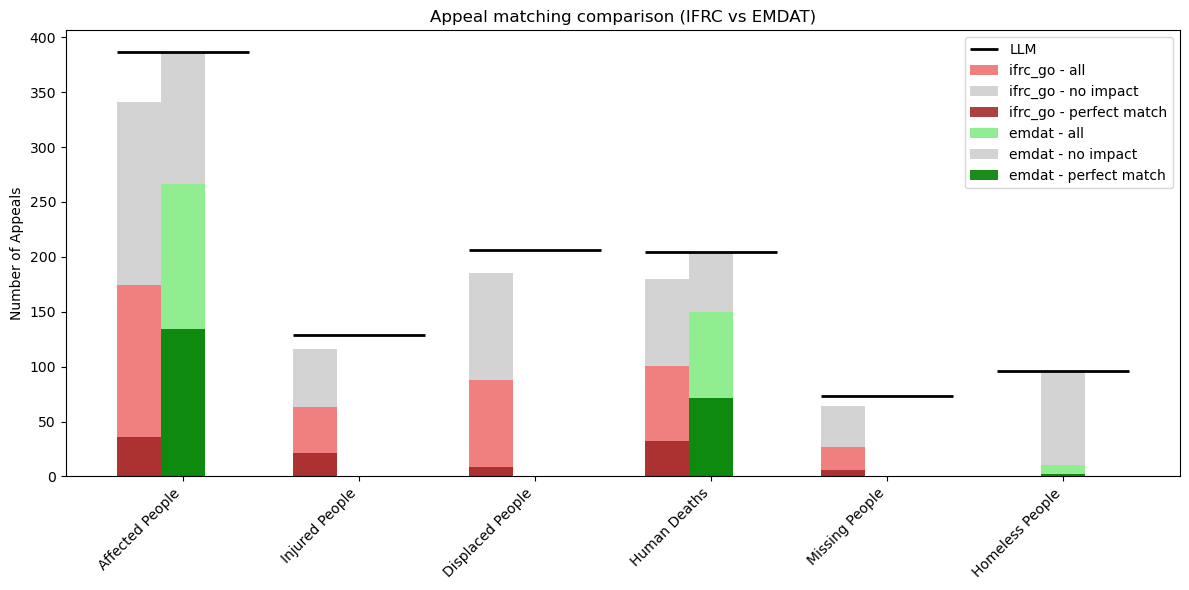

In [95]:
x = np.arange(len(mapping_impact_type.keys()))  # positions for bars
width = 0.25  # bar width

fig, ax = plt.subplots(figsize=(12,6))

# Define colors
colors = {
    "ifrc_monty": ["skyblue", "dodgerblue"],
    "emdat": ["lightgreen", "green"],
    "ifrc_go": ["lightcoral", "brown"],
}

for i, external_source in enumerate(["ifrc_go", "emdat"]):
    # Base bars ("all")
    bars_all = ax.bar(
        x + (i-1)*width,
        nb_matched[external_source],
        width,
        label=external_source + " - all",
        color=colors[external_source][0],
    )

    # Add stacked bar ("no external impact") on top of "all"
    ax.bar(
        x + (i-1)*width,
        nb_no_external_impact[external_source],
        width,
        bottom=nb_matched[external_source],
        label=external_source + " - no impact",
        color="lightgray",
        # edgecolor="gray",
    )

    # "Perfect match" bars
    ax.bar(
        x + (i-1)*width,
        nb_exact_match[external_source],
        width,
        label=external_source + " - perfect match",
        color=colors[external_source][1],
        alpha=0.9,
    )

# Target lines
total_bar_width = 3*width
for xi, y in zip(x, nb_extracted):
    ax.hlines(
        y=y,
        xmin=xi - total_bar_width/2,
        xmax=xi + total_bar_width/2,
        colors='black',
        linewidth=2,
        label="LLM" if xi == 0 else ""
    )

# Labels and formatting
ax.set_xticks(x)
ax.set_xticklabels(mapping_impact_type.keys(), rotation=45, ha="right")
ax.set_ylabel("Number of Appeals")
ax.set_title("Appeal matching comparison (IFRC vs EMDAT)")
ax.legend()
plt.tight_layout()
plt.show()

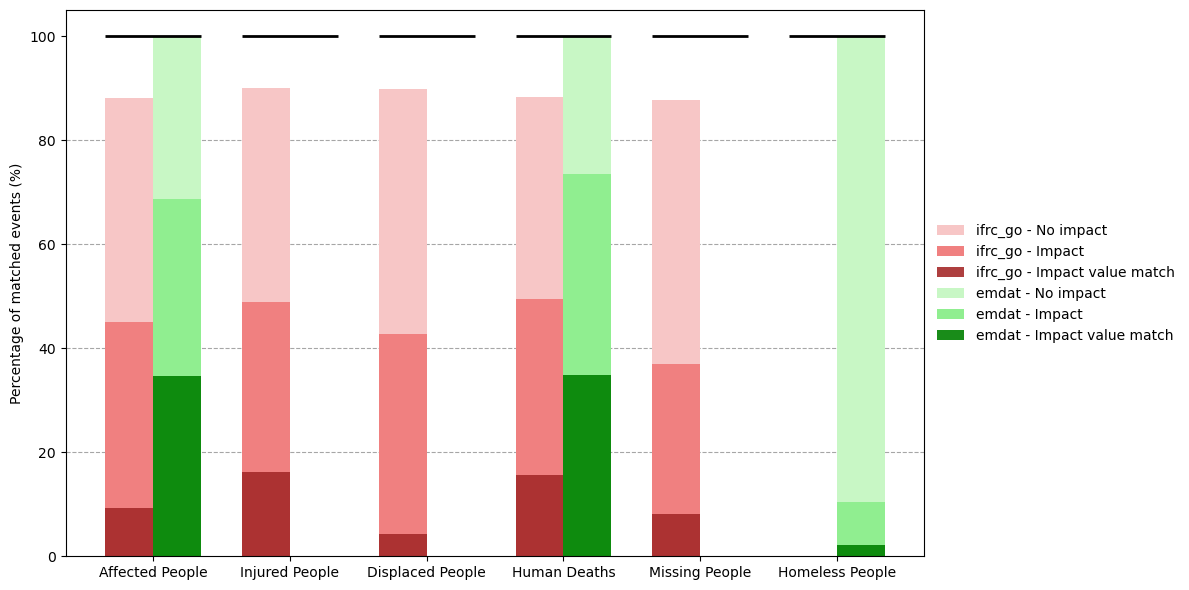

In [96]:
x = np.arange(len(mapping_impact_type.keys()))  # positions for bars
width = 0.35  # wider bar width

fig, ax = plt.subplots(figsize=(12, 6))

# Define colors
colors = {
    "emdat": {
        "all": "lightgreen",
        "no_impact": "#c8f7c5",  # very light green
        "exact": "green",
    },
    "ifrc_go": {
        "all": "lightcoral",
        "no_impact": "#f7c6c6",  # very light red
        "exact": "brown",
    },
}

# Convert counts to percentages of nb_extracted
nb_matched_pct = {k: (np.array(v) / np.array(nb_extracted)) * 100 for k, v in nb_matched.items()}
nb_no_external_impact_pct = {k: (np.array(v) / np.array(nb_extracted)) * 100 for k, v in nb_no_external_impact.items()}
nb_exact_match_pct = {k: (np.array(v) / np.array(nb_extracted)) * 100 for k, v in nb_exact_match.items()}

for i, external_source in enumerate(["ifrc_go", "emdat"]):
    offset = (i - 0.5) * width  # positions for side-by-side bars

    # Combine total (all + no external impact + exact match) as one stacked bar
    ax.bar(
        x + offset,
        nb_no_external_impact_pct[external_source],
        width,
        bottom=nb_matched_pct[external_source],
        label=external_source + " - No impact",
        color=colors[external_source]["no_impact"],
    )
    
    ax.bar(
        x + offset,
        nb_matched_pct[external_source],
        width,
        label=external_source + " - Impact",
        color=colors[external_source]["all"],
    )

    ax.bar(
        x + offset,
        nb_exact_match_pct[external_source],
        width,
        label=external_source + " - Impact value match",
        color=colors[external_source]["exact"],
        alpha=0.9,
    )

# Reference line at 100%
for xi in x:
    ax.hlines(
        y=100,
        xmin=xi - width,
        xmax=xi + width,
        colors='black',
        linewidth=2
    )

# Add dashed horizontal gridlines at 20, 40, 60, 80%
for y in [20, 40, 60, 80]:
    ax.axhline(y=y, color='gray', linestyle='--', linewidth=0.8, alpha=0.7, zorder=0)

# Labels and formatting
ax.set_xticks(x)
# ax.set_xticklabels(mapping_impact_type.keys(), rotation=45, ha="right")
ax.set_xticklabels(mapping_impact_type.keys())
ax.set_ylabel("Percentage of matched events (%)")
ax.set_ylim(0, 105)
# ax.set_title("Appeal matching comparison (IFRC vs EMDAT) — % of extracted appeals")
ax.legend()

# Move the legend box outside 
ax.legend(
    loc='center left',
    bbox_to_anchor=(1, 0.5),
    frameon=False
)
plt.tight_layout()

#Save fig 
# fig.savefig(path_save_fig / f"matched_events_ext_quanti_impact.png", 
#             transparent=True, bbox_inches='tight', dpi=300)
# fig.savefig(path_save_fig / f"matched_events_ext_quanti_impact.svg", 
#             format="svg", transparent=True, bbox_inches='tight', dpi=300)
# fig.savefig(path_save_fig / f"matched_events_ext_quanti_impact.pdf", 
#             format="pdf", transparent=True, bbox_inches='tight', dpi=300)

plt.show()

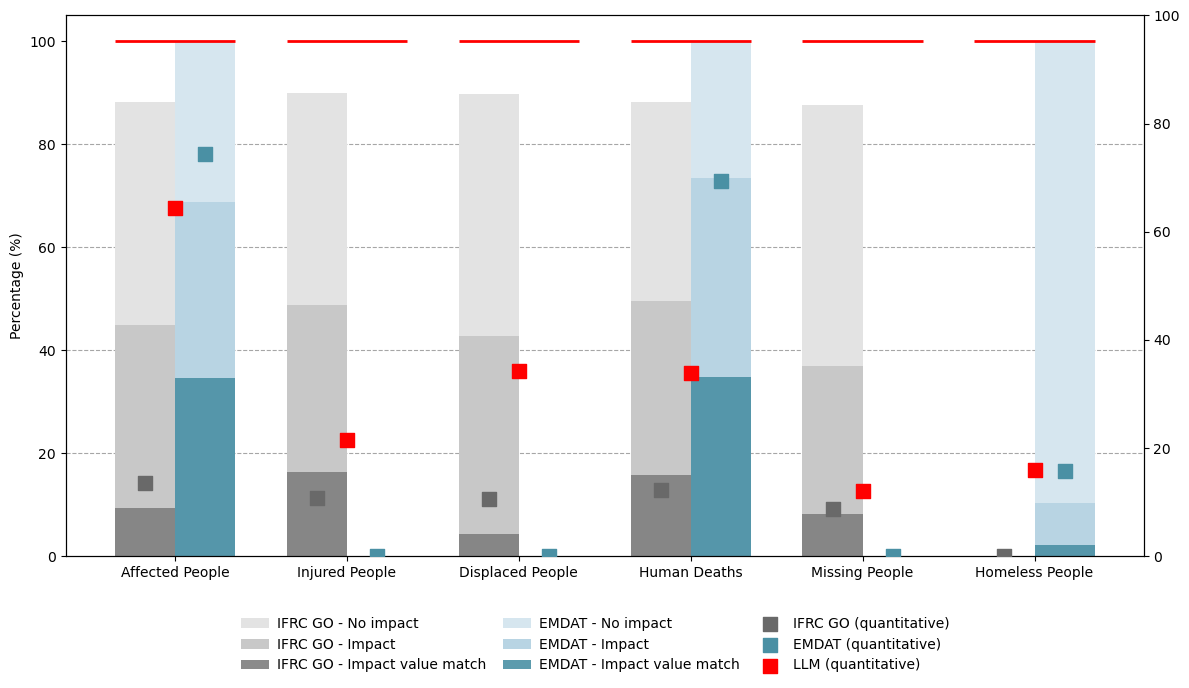

In [97]:
x = np.arange(len(mapping_impact_type.keys()))  # positions for bars
width = 0.35  # width for stacked bars

fig, ax = plt.subplots(figsize=(12, 6))

# Define colors
colors = {
    "emdat": {
        "all": "#b8d4e3",        # light desaturated blue
        "no_impact": "#d6e6ef",  # very light blue
        "exact": "#4a90a4",      # muted blue-grey
    },
    "ifrc_go": {
        "all": "#c8c8c8",        # light grey
        "no_impact": "#e3e3e3",  # very light grey
        "exact": "#7f7f7f",      # medium grey
    },
}


# Convert counts to percentages of nb_extracted
nb_matched_pct = {k: (np.array(v) / np.array(nb_extracted)) * 100 for k, v in nb_matched.items()}
nb_no_external_impact_pct = {k: (np.array(v) / np.array(nb_extracted)) * 100 for k, v in nb_no_external_impact.items()}
nb_exact_match_pct = {k: (np.array(v) / np.array(nb_extracted)) * 100 for k, v in nb_exact_match.items()}

# Main stacked bars
for i, external_source in enumerate(["ifrc_go", "emdat"]):
    offset = (i - 0.5) * width
    source_label = external_source.replace("_", " ").upper()

    # No external impact (top segment)
    ax.bar(
        x + offset,
        nb_no_external_impact_pct[external_source],
        width,
        bottom=nb_matched_pct[external_source],
        label=source_label + " - No impact",
        color=colors[external_source]["no_impact"],
    )

    # Matched (middle segment)
    ax.bar(
        x + offset,
        nb_matched_pct[external_source],
        width,
        label=source_label + " - Impact",
        color=colors[external_source]["all"],
    )

    # Exact match (overlay)
    ax.bar(
        x + offset,
        nb_exact_match_pct[external_source],
        width,
        label=source_label + " - Impact value match",
        color=colors[external_source]["exact"],
        alpha=0.9,
    )

# Reference 100% line
for xi in x:
    ax.hlines(y=100, xmin=xi - width, xmax=xi + width, colors='red', linewidth=2)

# Horizontal dashed lines
for y in [20, 40, 60, 80]:
    ax.axhline(y=y, color='gray', linestyle='--', linewidth=0.8, alpha=0.7, zorder=0)

# ---------- SECOND Y-AXIS ----------
ax2 = ax.twinx()

# Colors for quantitative markers
marker_color_ifrc = "dimgray"
marker_color_emdat = "#4a90a4"   # same as EMDAT exact bar
marker_color_llm = "red"         # as requested

# Positions aligned with bars
pos_ifrc_go = x - width/2
pos_emdat   = x + width/2
pos_llm     = x    # dedicated LLM slot

# Plot squares
ax2.scatter(
    pos_ifrc_go,
    perc_report_with_impact["ifrc_go"],
    marker='s',
    s=90,
    color=marker_color_ifrc,
    label="IFRC GO (quantitative)",
    zorder=12
)

ax2.scatter(
    pos_emdat,
    perc_report_with_impact["emdat"],
    marker='s',
    s=90,
    color=marker_color_emdat,
    label="EMDAT (quantitative)",
    zorder=12
)

ax2.scatter(
    pos_llm,
    perc_report_with_impact_llm,
    marker='s',
    s=90,
    color=marker_color_llm,
    label="LLM (quantitative)",
    zorder=12
)

# ax2.set_ylabel("Percentage of reports with quantitative data (%)")
ax2.set_ylim(0, 100)

# ---------- Formatting ----------
ax.set_xticks(x)
ax.set_xticklabels(mapping_impact_type.keys())
ax.set_ylabel("Percentage (%)")
ax.set_ylim(0, 105)

# Legends
# Combine legends from both axes
handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

handles = handles1 + handles2
labels = labels1 + labels2

# Put legend under the figure with at most 3 items per column
# We compute number of columns dynamically:
n_entries = len(labels)
n_cols = int(np.ceil(n_entries / 3))  # max 3 entries per column

fig.legend(
    handles,
    labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=n_cols,
    frameon=False,
    columnspacing=1.2,
    handletextpad=0.6
)

plt.tight_layout()

# Save fig
# fig.savefig(path_save_fig / "matched_events_ext_quanti_impact.png",
#             transparent=True, bbox_inches='tight', dpi=300)
# fig.savefig(path_save_fig / "matched_events_ext_quanti_impact.svg",
#             format="svg", transparent=True, bbox_inches='tight', dpi=300)
# fig.savefig(path_save_fig / "matched_events_ext_quanti_impact.pdf",
#             format="pdf", transparent=True, bbox_inches='tight', dpi=300)

plt.show()


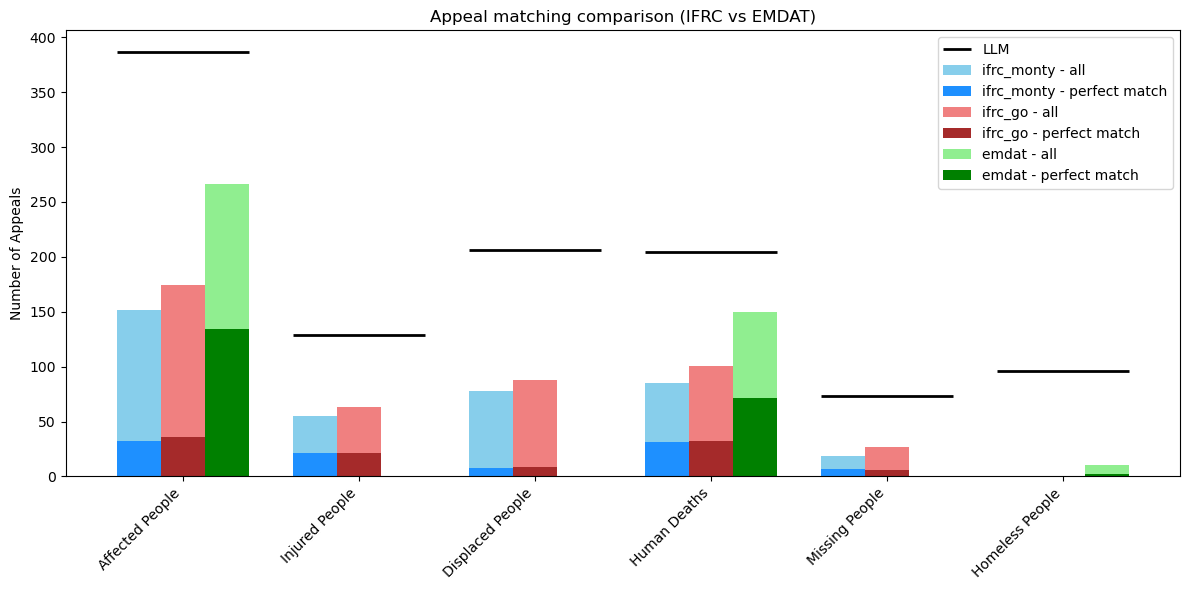

In [98]:
x = np.arange(len(mapping_impact_type.keys()))  # positions for bars
width = 0.25  # bar width

fig, ax = plt.subplots(figsize=(12,6))

# Define colors like in your previous example
colors = {}
colors["ifrc_monty"] = ["skyblue", "dodgerblue"]      # all / perfect match
colors["emdat"] = ["lightgreen", "green"]       # all / perfect match
colors["ifrc_go"] = ["lightcoral", "brown"]

for i, external_source in enumerate(nb_matched.keys()) : 
    # IFRC bars
    ax.bar(x + (i-1)*width, nb_matched[external_source], width, label=external_source+" - all", color=colors[external_source][0])
    ax.bar(x + (i-1)*width, nb_exact_match[external_source], width, label=external_source+" - perfect match", color=colors[external_source][1])

    # # EMDAT bars
    # ax.bar(x + (i-1)*width, nb_matched_emdat, width, label="EMDAT - all", color=colors_emdat[0])
    # ax.bar(x + (i-1)*width, nb_exact_match_emdat, width, label="EMDAT - perfect match", color=colors_emdat[1])

    # # EMDAT bars
    # ax.bar(x + (i-1)*width, nb_matched_emdat, width, label="EMDAT - all", color=colors_emdat[0])
    # ax.bar(x + (i-1)*width, nb_exact_match_emdat, width, label="EMDAT - perfect match", color=colors_emdat[1])

# Target
total_bar_width = 3*width
for xi, y in zip(x, nb_extracted):
    ax.hlines(y=y, xmin=xi - total_bar_width/2, xmax=xi + total_bar_width/2,
              colors='black', linewidth=2, label="LLM" if xi == 0 else "")


# Labels
ax.set_xticks(x)
ax.set_xticklabels(mapping_impact_type.keys(), rotation=45, ha="right")
ax.set_ylabel("Number of Appeals")
ax.set_title("Appeal matching comparison (IFRC vs EMDAT)")
ax.legend()

plt.tight_layout()
plt.show()

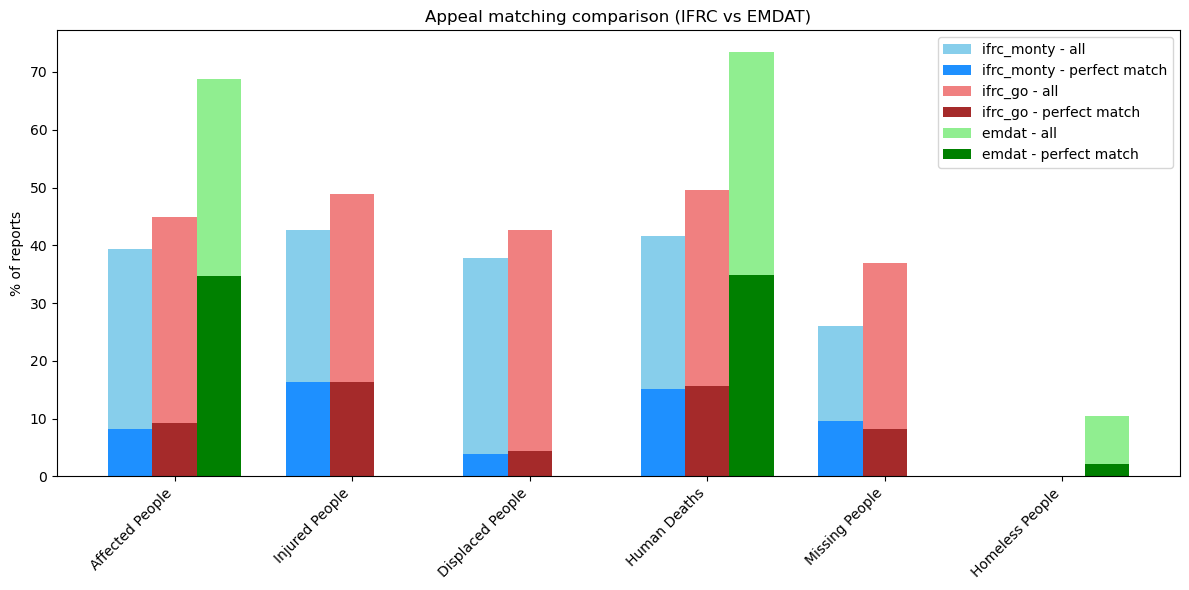

In [99]:
x = np.arange(len(mapping_impact_type.keys()))  # positions for bars
width = 0.25  # bar width

fig, ax = plt.subplots(figsize=(12,6))

# Define colors like in your previous example
colors = {}
colors["ifrc_monty"] = ["skyblue", "dodgerblue"]      # all / perfect match
colors["emdat"] = ["lightgreen", "green"]       # all / perfect match
colors["ifrc_go"] = ["lightcoral", "brown"]

for i, external_source in enumerate(nb_matched.keys()) : 
    # IFRC bars
    ax.bar(x + (i-1)*width, [100*matched / extracted for matched, extracted in zip(nb_matched[external_source], nb_extracted)], width, label=external_source+" - all", color=colors[external_source][0])
    ax.bar(x + (i-1)*width, [100*matched / extracted for matched, extracted in zip(nb_exact_match[external_source], nb_extracted)], width, label=external_source+" - perfect match", color=colors[external_source][1])

    # # EMDAT bars
    # ax.bar(x + (i-1)*width, nb_matched_emdat, width, label="EMDAT - all", color=colors_emdat[0])
    # ax.bar(x + (i-1)*width, nb_exact_match_emdat, width, label="EMDAT - perfect match", color=colors_emdat[1])

    # # EMDAT bars
    # ax.bar(x + (i-1)*width, nb_matched_emdat, width, label="EMDAT - all", color=colors_emdat[0])
    # ax.bar(x + (i-1)*width, nb_exact_match_emdat, width, label="EMDAT - perfect match", color=colors_emdat[1])

# # Target
# total_bar_width = 3*width
# for xi, y in zip(x, nb_extracted):
#     ax.hlines(y=y, xmin=xi - total_bar_width/2, xmax=xi + total_bar_width/2,
#               colors='black', linewidth=2, label="LLM" if xi == 0 else "")


# Labels
ax.set_xticks(x)
ax.set_xticklabels(mapping_impact_type.keys(), rotation=45, ha="right")
ax.set_ylabel(r"% of reports")
ax.set_title("Appeal matching comparison (IFRC vs EMDAT)")
ax.legend()

plt.tight_layout()
plt.show()

## Error plot

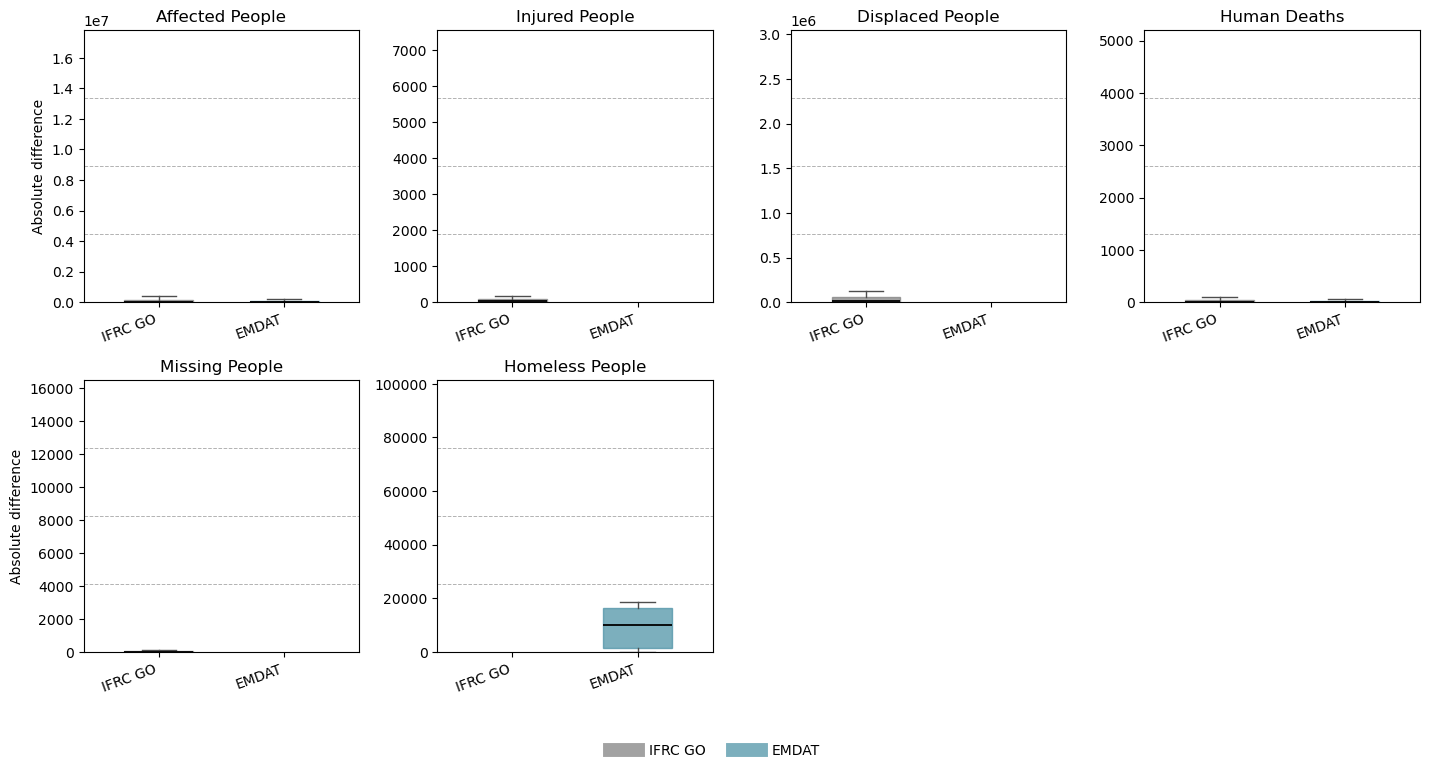

In [129]:
# Absolute difference boxplots with independent y-axis per impact category
impact_categories = list(mapping_impact_type.keys())

# Colors aligned with your previous figure
color_ifrc = "#7f7f7f"   # medium grey
color_emdat = "#4a90a4"  # muted blue-grey

n_categories = len(impact_categories)
n_cols = min(4, n_categories)
n_rows = int(np.ceil(n_categories / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(3.6 * n_cols, 3.8 * n_rows),
    sharey=False,
)

if isinstance(axes, np.ndarray):
    axes = axes.flatten()
else:
    axes = np.array([axes])

for i, impactSubtype in enumerate(impact_categories):
    ax = axes[i]

    vals_ifrc = (
        df_matched_with_impact.get("ifrc_go", pd.DataFrame())
        .loc[lambda d: d["impactSubtype"] == impactSubtype, "abs_diff"]
        .dropna()
        .values
    )
    vals_emdat = (
        df_matched_with_impact.get("emdat", pd.DataFrame())
        .loc[lambda d: d["impactSubtype"] == impactSubtype, "abs_diff"]
        .dropna()
        .values
    )

    box_data = []
    positions = []
    colors = []

    if len(vals_ifrc) > 0:
        box_data.append(vals_ifrc)
        positions.append(1)
        colors.append(color_ifrc)

    if len(vals_emdat) > 0:
        box_data.append(vals_emdat)
        positions.append(2)
        colors.append(color_emdat)

    if box_data:
        bp = ax.boxplot(
            box_data,
            positions=positions,
            widths=0.55,
            patch_artist=True,
            showfliers=False,
        )

        for patch, c in zip(bp["boxes"], colors):
            patch.set_facecolor(c)
            patch.set_alpha(0.72)
            patch.set_edgecolor(c)

        for median in bp["medians"]:
            median.set_color("black")
            median.set_linewidth(1.3)

        for whisker in bp["whiskers"]:
            whisker.set_color("#4d4d4d")

        for cap in bp["caps"]:
            cap.set_color("#4d4d4d")

        panel_vals = np.concatenate([arr for arr in box_data if len(arr) > 0])
        ymax = np.nanmax(panel_vals) if len(panel_vals) else 1.0
        if not np.isfinite(ymax) or ymax <= 0:
            ymax = 1.0

        ax.set_ylim(0, ymax * 1.10)
        grid_levels = np.linspace(0, ymax * 1.10, 5)[1:-1]
        for y in grid_levels:
            ax.axhline(y=y, color="gray", linestyle="--", linewidth=0.7, alpha=0.6, zorder=0)
    else:
        ax.set_ylim(0, 1)

    ax.set_xlim(0.4, 2.6)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(["IFRC GO", "EMDAT"], rotation=20, ha="right")
    ax.set_title(impactSubtype)

for j in range(n_categories, len(axes)):
    axes[j].axis("off")

for r in range(n_rows):
    axes[r * n_cols].set_ylabel("Absolute difference")

legend_handles = [
    plt.Line2D([0], [0], color=color_ifrc, lw=10, alpha=0.72, label="IFRC GO"),
    plt.Line2D([0], [0], color=color_emdat, lw=10, alpha=0.72, label="EMDAT"),
]

fig.legend(
    handles=legend_handles,
    labels=["IFRC GO", "EMDAT"],
    loc="lower center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=2,
    frameon=False,
)

plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

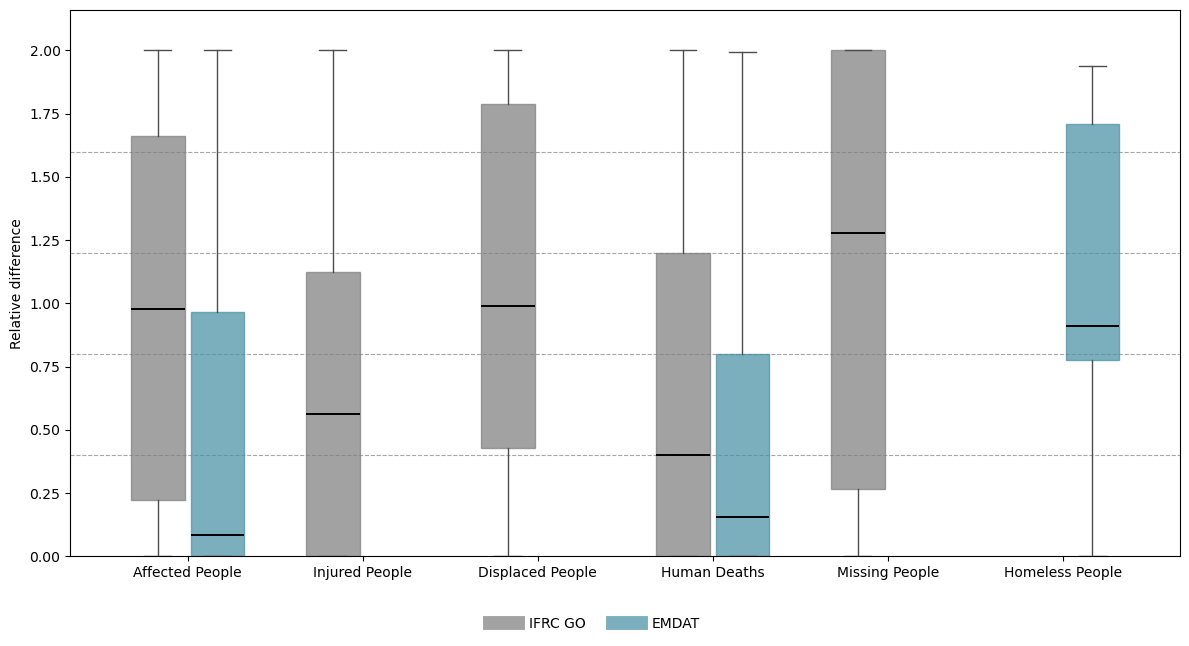

In [128]:
# Relative difference boxplot by impact category (style aligned with the stacked chart)
impact_categories = list(mapping_impact_type.keys())
x = np.arange(len(impact_categories))
width = 0.34

# Colors aligned with your previous figure
color_ifrc = "#7f7f7f"   # medium grey
color_emdat = "#4a90a4"  # muted blue-grey

fig, ax = plt.subplots(figsize=(12, 6))

# Build grouped boxplot data
box_data = []
box_positions = []
box_colors = []

for i, impactSubtype in enumerate(impact_categories):
    vals_ifrc = (
        df_matched_with_impact.get("ifrc_go", pd.DataFrame())
        .loc[lambda d: d["impactSubtype"] == impactSubtype, "rel_diff"]
        .dropna()
        .values
    )
    vals_emdat = (
        df_matched_with_impact.get("emdat", pd.DataFrame())
        .loc[lambda d: d["impactSubtype"] == impactSubtype, "rel_diff"]
        .dropna()
        .values
    )

    if len(vals_ifrc) > 0:
        box_data.append(vals_ifrc)
        box_positions.append(i - width / 2)
        box_colors.append(color_ifrc)

    if len(vals_emdat) > 0:
        box_data.append(vals_emdat)
        box_positions.append(i + width / 2)
        box_colors.append(color_emdat)

bp = ax.boxplot(
    box_data,
    positions=box_positions,
    widths=width * 0.9,
    patch_artist=True,
    showfliers=False,
)

for patch, c in zip(bp["boxes"], box_colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.72)
    patch.set_edgecolor(c)

for median in bp["medians"]:
    median.set_color("black")
    median.set_linewidth(1.4)

for whisker in bp["whiskers"]:
    whisker.set_color("#4d4d4d")

for cap in bp["caps"]:
    cap.set_color("#4d4d4d")

# Horizontal dashed gridlines (as in your bar chart)
ymax = np.nanmax(np.concatenate([arr for arr in box_data if len(arr) > 0])) if box_data else 1
if not np.isfinite(ymax) or ymax <= 0:
    ymax = 1

grid_levels = np.linspace(0, ymax, 6)[1:-1]
for y in grid_levels:
    ax.axhline(y=y, color="gray", linestyle="--", linewidth=0.8, alpha=0.7, zorder=0)

# Formatting
ax.set_xticks(x)
ax.set_xticklabels(impact_categories)
ax.set_ylabel("Relative difference")
ax.set_ylim(0, ymax * 1.08)

# Legend under plot
legend_handles = [
    plt.Line2D([0], [0], color=color_ifrc, lw=10, alpha=0.72, label="IFRC GO"),
    plt.Line2D([0], [0], color=color_emdat, lw=10, alpha=0.72, label="EMDAT"),
]

fig.legend(
    handles=legend_handles,
    labels=["IFRC GO", "EMDAT"],
    loc="lower center",
    bbox_to_anchor=(0.5, -0.08),
    ncol=2,
    frameon=False,
)

plt.tight_layout()
plt.show()

In [111]:
df_matched_with_impact["ifrc_go"][1]

,impactValue_final,location,locationOsm,impactSubtype,impactValue,impactValuePrecision,impactUnit,valueAnnotation,valid_errors_impactValue,locationAnnotation,...,parent_event,slug,summary,tab_one_title,tab_three_title,tab_two_title,translation_module_original_language,updated_at,rel_diff,match
32,124.0,Khost; Zabul; Faryab; Farah; Kapisa; Kunar; Ku...,Faryab Province; Herat; Nangarhar Province; Pa...,Injured People,124.0,exact,people,"[As of 28 August, 141 fatalities were reported...",0,"[As of 28 August, 141 fatalities were reported...",...,NaN,NaN,"<p class=""MsoNoSpacing"" style=""text-align: jus...",Additional Information,NaN,NaN,en,2024-06-03T18:15:18.094806Z,0.000000,True
39,84.0,Badakhshan; Badghis; Baghlan; Balkh; Diakindi;...,Badghis Province; Baghlan Province; Balkh; Gho...,Injured People,84.0,exact,people,"[A total of 41 deaths, 84 injuries, 8,273 dama...",0,"[A total of 41 deaths, 84 injuries, 8,273 dama...",...,NaN,NaN,"<p class=""MsoNormal"" style=""text-align: justif...",Additional Information,NaN,NaN,en,2024-05-25T05:17:32.889099Z,0.000000,True
224,4.0,Kiyange 1 and Ngagara-Sabe areas; Gatumba,Gatumba; Burundi,Injured People,4.0,exact,people,[This situation left 1 death and 4 injuries.],0,"[This situation left 1 death and 4 injuries., ...",...,NaN,NaN,ButerereBURUNDI has experienced unprecedented ...,Additional Information,NaN,NaN,en,2024-06-03T18:20:21.463237Z,0.000000,True
340,220.0,Kalehe Territory; South Kivu Province; Bushush...,Democratic Republic of Congo; Bushushu; Nyamukubi,Injured People,220.0,exact,people,[The injured needed to be rescued and evacuate...,0,[The disaster created vulnerabilities and had ...,...,NaN,NaN,"<p><span style=""font-size: 11.0pt; line-height...",Additional Information,NaN,NaN,fr,2024-06-03T12:29:08.459102Z,0.500000,False
354,11.0,Kalemie; Moba,Kalemie; Democratic Republic of Congo,Injured People,11.0,exact,people,[11 deaths and 8 injuries were reported in Kal...,0,[11 deaths and 8 injuries were reported in Kal...,...,NaN,NaN,"<p class=""MsoNormal"" style=""text-align: justif...",Additional Information,NaN,NaN,fr,2024-07-14T20:02:45.687598Z,0.482759,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2618,1908.0,northern Viet Nam; northern mountainous provin...,Hòa Bình Province; Yên Bái Province; Sơn La Pr...,Injured People,1908.0,exact,people,"[The VNDDMA reported 262 fatalities, 83 missin...",0,"[The report confirmed 262 fatalities, 83 missi...",...,NaN,NaN,<p>Cyclone Yagi has steadily strengthened all ...,Additional Information,NaN,NaN,en,2025-07-16T00:43:11.029197Z,0.000000,True
2643,28.0,,Yemen,Injured People,28.0,exact,people,"[According to reported data, over 205,800 peop...",0,"[According to reported data, over 205,800 peop...",...,NaN,NaN,NaN,Additional Information,NaN,NaN,en,2021-07-22T14:59:11.547641Z,0.727273,False
2649,41.0,,Yemen,Injured People,41.0,exact,people,"[Up till May 11th, YRCS needs' tracking report...",0,"[Up till May 11th, YRCS needs' tracking report...",...,NaN,NaN,"<p class=""MsoNormal"" style=""text-align: justif...",Additional Information,NaN,NaN,en,2024-06-03T18:13:17.321543Z,0.000000,True
2653,150.0,Al-Mahra Governorate; Hadramout; Shabwa; Al Gh...,Socotra Governorate; Hadramout - Ma'rib Road; ...,Injured People,150.0,exact,people,[More than 150 people were injured.],0,"[The reports of widespread ﬂooding, infrastruc...",...,NaN,NaN,<p>Tropical cyclone TEJ made landfall over the...,Additional Information,NaN,NaN,en,2023-11-02T09:32:11.319114Z,0.006645,True


In [109]:
error = {}
relative_error = {}
abs_relative_error = {}
mae = {}
rmse = {}

for external_source in ["emdat", "ifrc_go"] : 
    error[external_source] = []
    relative_error[external_source] = []
    abs_relative_error[external_source] = []
    mae[external_source] = []
    rmse[external_source] = []
    for impactSubtype in mapping_impact_type.keys() : 
        col = mapping_impact_type[impactSubtype][external_source]
        if col is None :
            mae[external_source].append(0)
            rmse[external_source].append(0)
            error[external_source].append(0)
            abs_relative_error[external_source].append(0)
            relative_error[external_source].append(0)
            continue

        df_matched = df_llm_all_geo_grp_linked[external_source].loc[df_llm_all_geo_grp_linked[external_source]["impactSubtype"] == impactSubtype]

        if external_source == "ifrc_go" : 
            df_matched["external_value"] = df_matched[impactSubtype]

        elif external_source == "emdat" : 
            df_matched["external_value"] = df_matched[col]

        df_matched = df_matched.dropna(subset=["external_value"])
        # Add errors metrics
        df_matched["error"] = df_matched["external_value"] - df_matched["impactValue_final"]

        df_matched["abs_relative_error"] = np.abs(df_matched["impactValue_final"] - df_matched["external_value"])/df_matched["impactValue_final"]
        df_matched["relative_error"] = (df_matched["impactValue_final"] - df_matched["external_value"])/df_matched["impactValue_final"]

        df_matched["abs_error"] = (df_matched["impactValue_final"] - df_matched["external_value"]).abs()

        # Squared error per row (for RMSE)
        df_matched["squared_error"] = (df_matched["impactValue_final"] - df_matched["external_value"])**2

        error[external_source].append(df_matched["error"].mean())
        relative_error[external_source].append(df_matched["relative_error"].mean())
        abs_relative_error[external_source].append(df_matched["abs_relative_error"].mean())
        mae[external_source].append(df_matched["abs_error"].mean())
        rmse[external_source].append(np.sqrt(df_matched["squared_error"].mean()))

C:\Users\lhasbini\AppData\Local\Temp\ipykernel_26476\3575627123.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_matched["external_value"] = df_matched[col]
C:\Users\lhasbini\AppData\Local\Temp\ipykernel_26476\3575627123.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_matched["external_value"] = df_matched[col]
C:\Users\lhasbini\AppData\Local\Temp\ipykernel_26476\3575627123.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_in

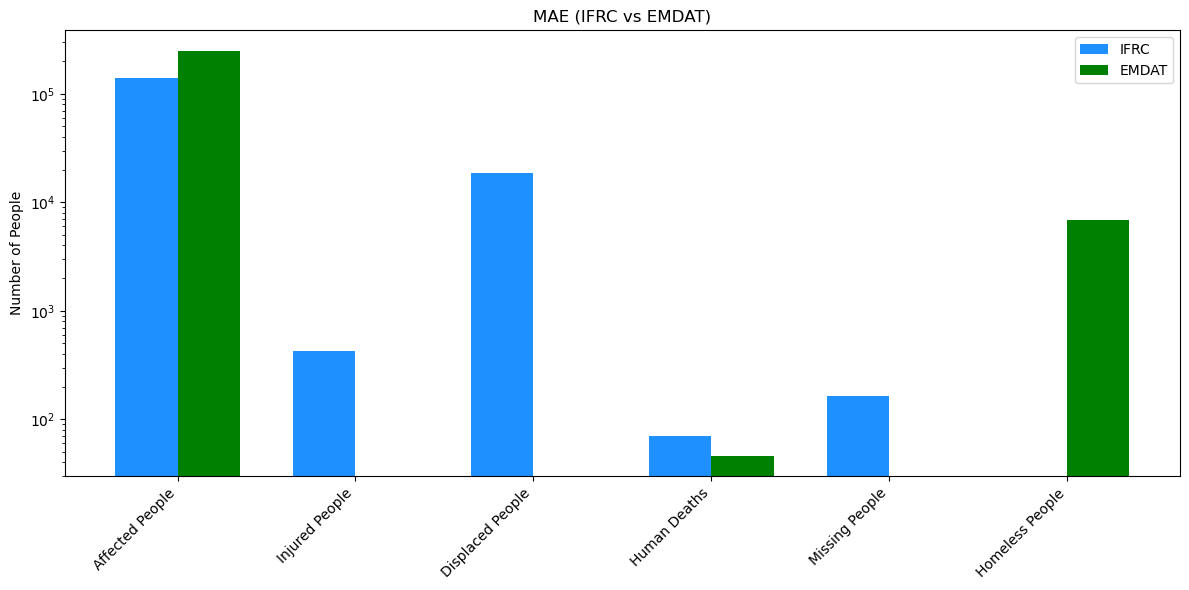

In [103]:
x = np.arange(len(mapping_impact_type.keys()))  # positions for bars
width = 0.35  # bar width

fig, ax = plt.subplots(figsize=(12,6))

# Define colors like in your previous example
colors_ifrc = ["skyblue", "dodgerblue"]      # all / perfect match
colors_emdat = ["lightgreen", "green"]       # all / perfect match

# IFRC bars
# ax.bar(x - width/2, nb_matched_ifrc, width, label="IFRC - all", color=colors_ifrc[0])
ax.bar(x - width/2, mae["ifrc_go"], width, label="IFRC", color=colors_ifrc[1])

# EMDAT bars
# ax.bar(x + width/2, nb_matched_emdat, width, label="EMDAT - all", color=colors_emdat[0])
ax.bar(x + width/2, mae["emdat"], width, label="EMDAT", color=colors_emdat[1])

# Labels
ax.set_xticks(x)
ax.set_xticklabels(mapping_impact_type.keys(), rotation=45, ha="right")
ax.set_ylabel("Number of People")
ax.set_title("MAE (IFRC vs EMDAT)")
ax.set_yscale("log")
ax.legend()

plt.tight_layout()
plt.show()

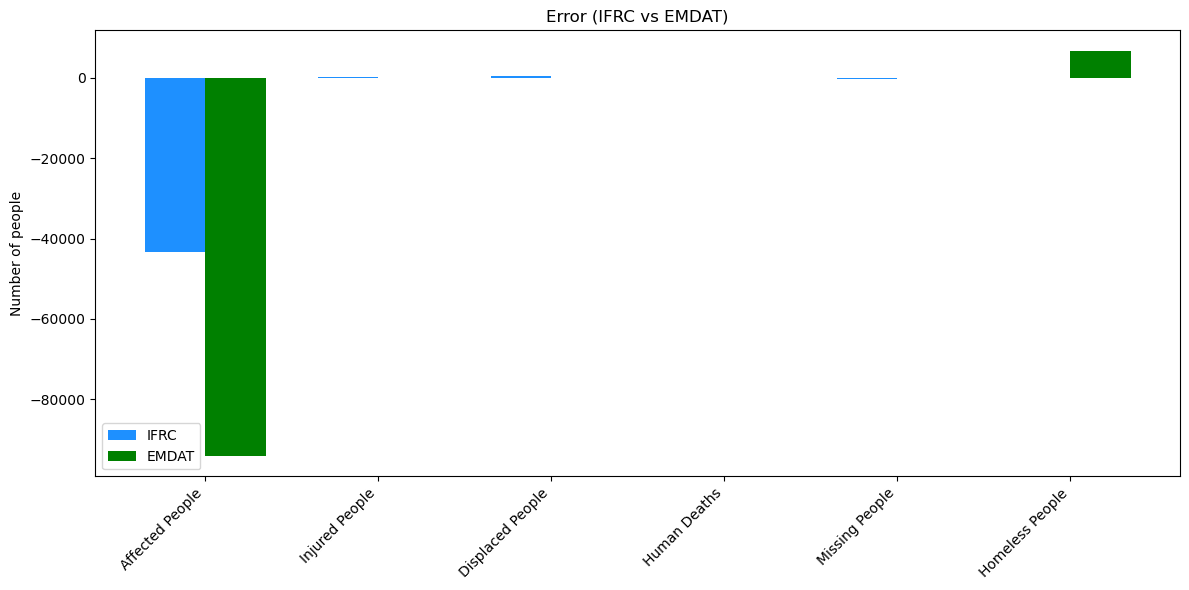

In [104]:
x = np.arange(len(mapping_impact_type.keys()))  # positions for bars
width = 0.35  # bar width

fig, ax = plt.subplots(figsize=(12,6))

# Define colors like in your previous example
colors_ifrc = ["skyblue", "dodgerblue"]      # all / perfect match
colors_emdat = ["lightgreen", "green"]       # all / perfect match

# IFRC bars
# ax.bar(x - width/2, nb_matched_ifrc, width, label="IFRC - all", color=colors_ifrc[0])
ax.bar(x - width/2, error["ifrc_go"], width, label="IFRC", color=colors_ifrc[1])

# EMDAT bars
# ax.bar(x + width/2, nb_matched_emdat, width, label="EMDAT - all", color=colors_emdat[0])
ax.bar(x + width/2, error["emdat"], width, label="EMDAT", color=colors_emdat[1])

# Labels
ax.set_xticks(x)
ax.set_xticklabels(mapping_impact_type.keys(), rotation=45, ha="right")
ax.set_ylabel("Number of people")
ax.set_title("Error (IFRC vs EMDAT)")
# ax.set_yscale("log")
ax.legend()

plt.tight_layout()
plt.show()

c:\Users\lhasbini\anaconda3\envs\ifrc_llm_311\Lib\site-packages\matplotlib\transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),
c:\Users\lhasbini\anaconda3\envs\ifrc_llm_311\Lib\site-packages\matplotlib\transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),


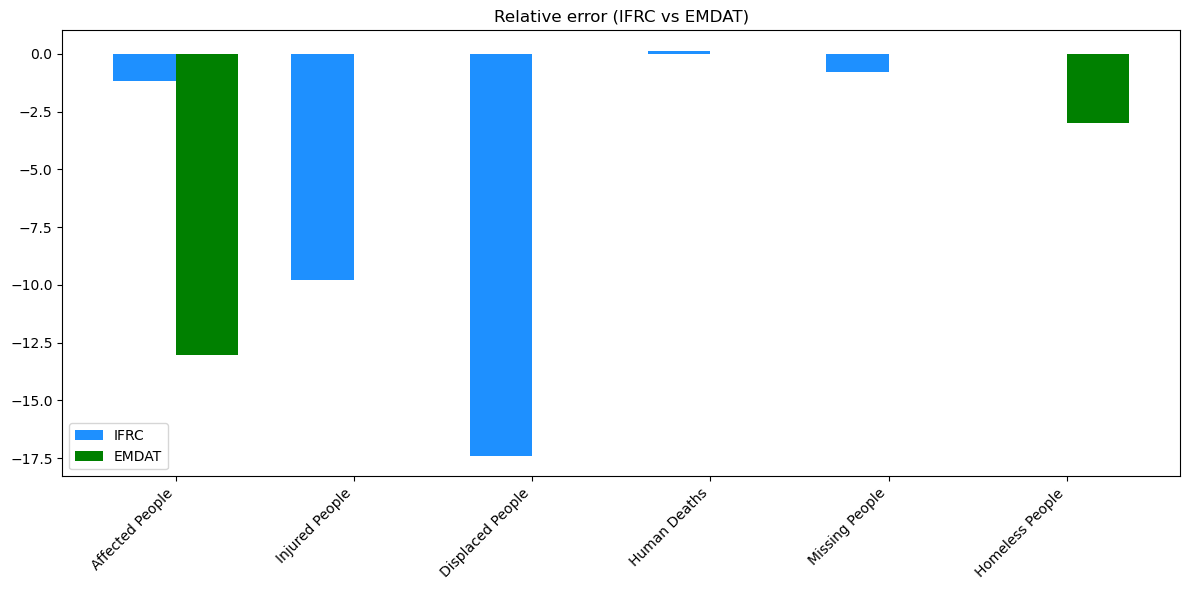

In [110]:
x = np.arange(len(mapping_impact_type.keys()))  # positions for bars
width = 0.35  # bar width

fig, ax = plt.subplots(figsize=(12,6))

# Define colors like in your previous example
colors_ifrc = ["skyblue", "dodgerblue"]      # all / perfect match
colors_emdat = ["lightgreen", "green"]       # all / perfect match

# IFRC bars
# ax.bar(x - width/2, nb_matched_ifrc, width, label="IFRC - all", color=colors_ifrc[0])
ax.bar(x - width/2, relative_error["ifrc_go"], width, label="IFRC", color=colors_ifrc[1])

# EMDAT bars
# ax.bar(x + width/2, nb_matched_emdat, width, label="EMDAT - all", color=colors_emdat[0])
ax.bar(x + width/2, relative_error["emdat"], width, label="EMDAT", color=colors_emdat[1])

# Labels
ax.set_xticks(x)
ax.set_xticklabels(mapping_impact_type.keys(), rotation=45, ha="right")
# ax.set_ylabel("Number of Appeals")
ax.set_title("Relative error (IFRC vs EMDAT)")
# ax.set_yscale("log")
ax.legend()

plt.tight_layout()
plt.show()

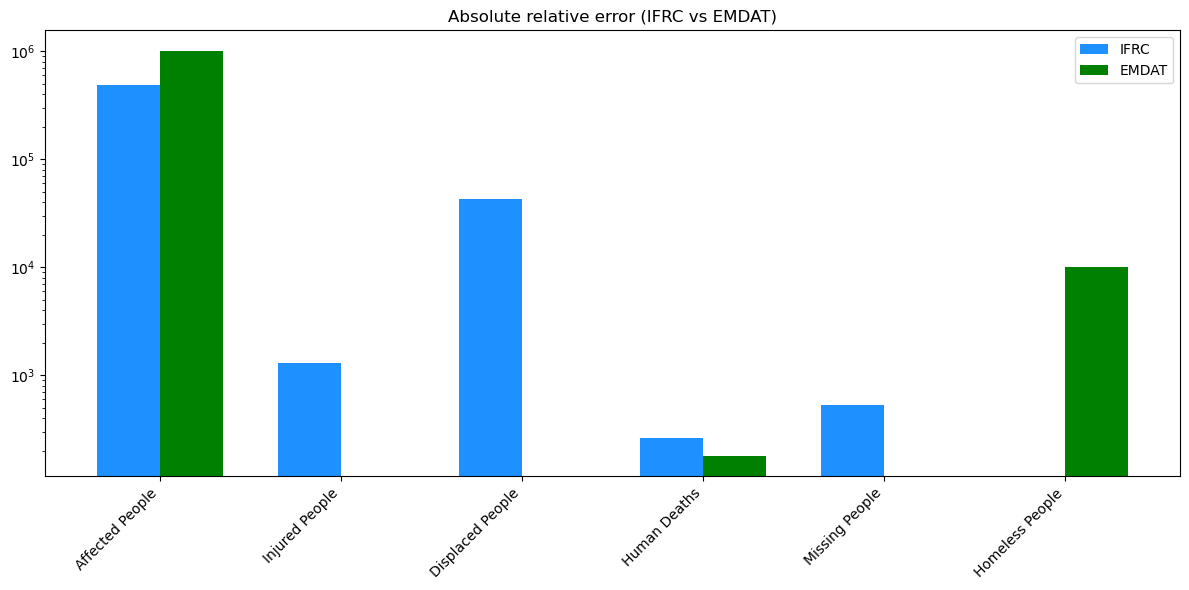

In [106]:
x = np.arange(len(mapping_impact_type.keys()))  # positions for bars
width = 0.35  # bar width

fig, ax = plt.subplots(figsize=(12,6))

# Define colors like in your previous example
colors_ifrc = ["skyblue", "dodgerblue"]      # all / perfect match
colors_emdat = ["lightgreen", "green"]       # all / perfect match

# IFRC bars
# ax.bar(x - width/2, nb_matched_ifrc, width, label="IFRC - all", color=colors_ifrc[0])
ax.bar(x - width/2, rmse["ifrc_go"], width, label="IFRC", color=colors_ifrc[1])

# EMDAT bars
# ax.bar(x + width/2, nb_matched_emdat, width, label="EMDAT - all", color=colors_emdat[0])
ax.bar(x + width/2, rmse["emdat"], width, label="EMDAT", color=colors_emdat[1])

# Labels
ax.set_xticks(x)
ax.set_xticklabels(mapping_impact_type.keys(), rotation=45, ha="right")
# ax.set_ylabel("Number of Appeals")
ax.set_title("Absolute relative error (IFRC vs EMDAT)")
ax.set_yscale("log")
ax.legend()

plt.tight_layout()
plt.show()

## Bar plot comparison

In [ ]:
from matplotlib.ticker import ScalarFormatter
def plot_em_dat_comparison(df_llm_geo_grp, df_labelled_geo_grp, df_emdat_linked, df_impact_ifrc_monty_appeal, df_go, appealCodelist, impactType, mapping_impact_type):
    # LLM EXTRACTED
    df1 = (
        df_llm_geo_grp[(df_llm_geo_grp["impactSubtype"] == impactType) &
                       (df_llm_geo_grp["appealCode"].isin(appealCodelist))]
        [["appealCode", "impactValue_final"]]
        .groupby("appealCode", as_index=False)
        .sum()
        .rename(columns={"impactValue_final": "LLM_extracted"})
    )

    # MANUALLY LABELLED
    df2 = (
        df_labelled_geo_grp[(df_labelled_geo_grp["impactSubtype"] == impactType) &
                       (df_labelled_geo_grp["appealCode"].isin(appealCodelist))]
        [["appealCode", "impactValue_final"]]
        .groupby("appealCode", as_index=False)
        .sum()
        .rename(columns={"impactValue_final": "Manual_labelling"})
    )

    # EMDAT MATCHING
    emdat_col = mapping_impact_type[impactType]["emdat"]
    if emdat_col is not None:
        df3 = (
            df_emdat_linked.loc[df_emdat_linked["appealCode"].isin(appealCodelist), ["appealCode", emdat_col]]
            .rename(columns={emdat_col: "EM-DAT"})
            .drop_duplicates()
        )
    else:
        # No EMDAT data available for this impact type
        df3 = pd.DataFrame({"appealCode": appealCodelist, "EM-DAT": [np.nan]*len(appealCodelist)})


    # IFRC MONTY
    df4 = (
        df_impact_ifrc_monty_appeal[(df_impact_ifrc_monty_appeal["impact_type"] == mapping_impact_type[impactType]["ifrc_monty"])&
                                    (df_impact_ifrc_monty_appeal["appealCode"].isin(appealCodelist))]
        [["appealCode", "impact_value"]]
        .groupby("appealCode", as_index=False)
        .sum()
        .rename(columns={"impact_value": "IFRC_Monty"})
    )

    # IFRC GO
    df5 = df_go[["appealCode", mapping_impact_type[impactType]["ifrc_go"]]].loc[df_go["appealCode"].isin(appealCodelist)].rename(
        columns={mapping_impact_type[impactType]["ifrc_go"] : "IFRC_GO"}
    )

    # --- Merge all together ---
    df_all = df1.merge(df2, on="appealCode", how="outer").merge(df3, on="appealCode", how="outer").merge(df4, on="appealCode", how="outer").merge(df5, on="appealCode", how="outer")

    # --- Plot ---
    ax = df_all.set_index("appealCode").plot(
        kind="bar", figsize=(12, 6), width=0.8, logy=True
    )

    # Format y-axis to switch to scientific notation for large values
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((-3, 3))  # auto switch if values <1e-3 or >1e3
    ax.yaxis.set_major_formatter(formatter)

    plt.title(f"Number of {impactType} by Appeal Code (Comparison of Sources)")
    plt.xlabel("Appeal Code")
    plt.ylabel(f"Number of {impactType}")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    return df_all


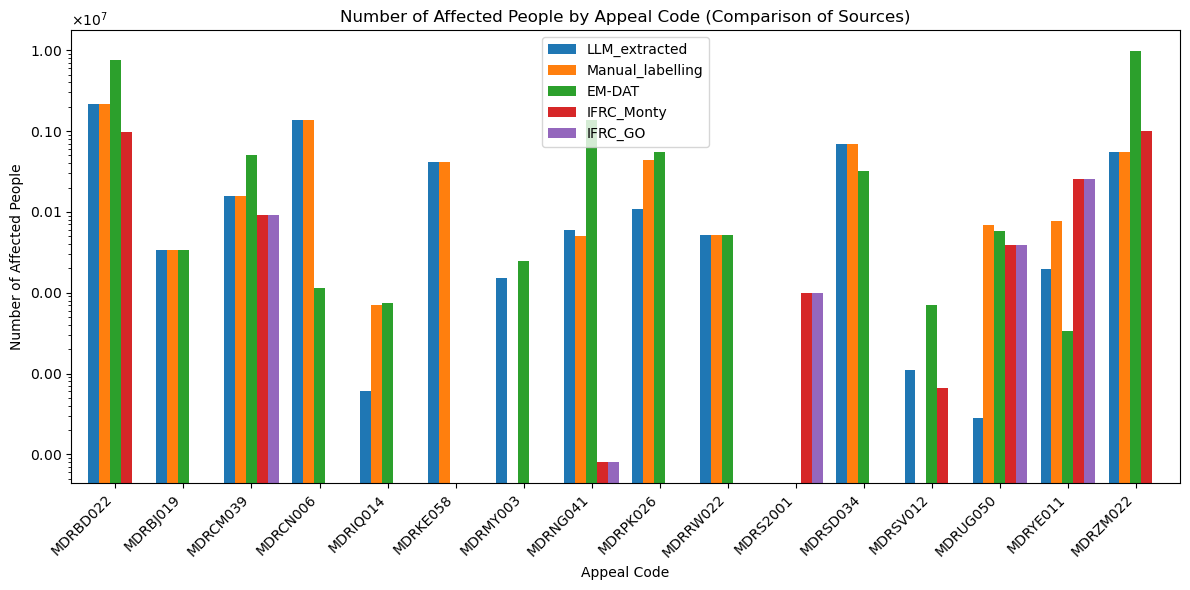

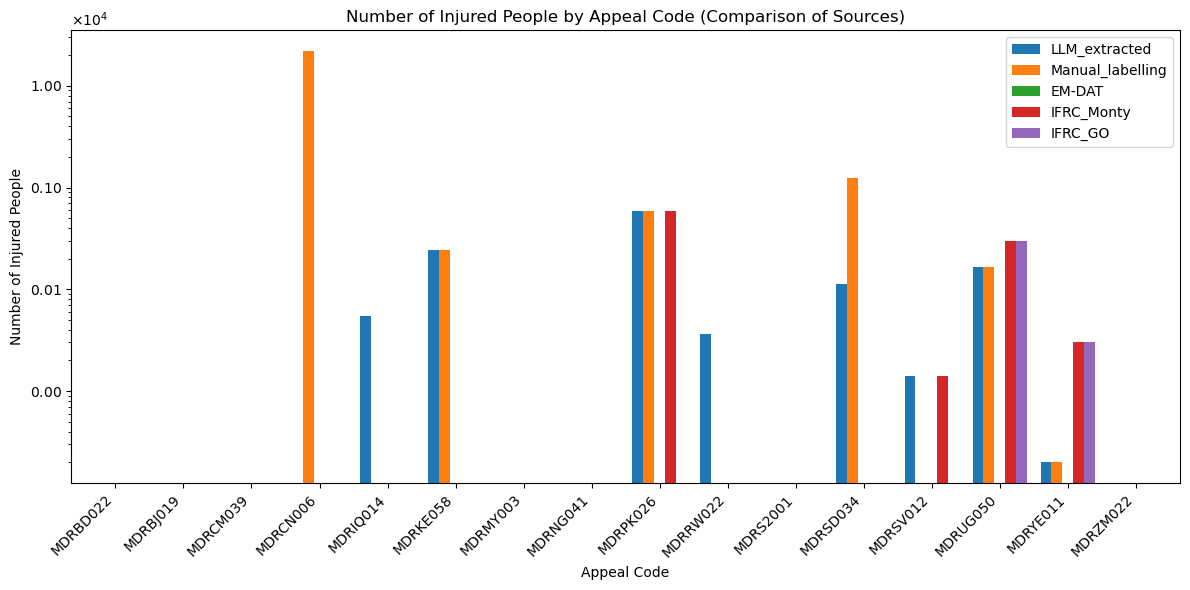

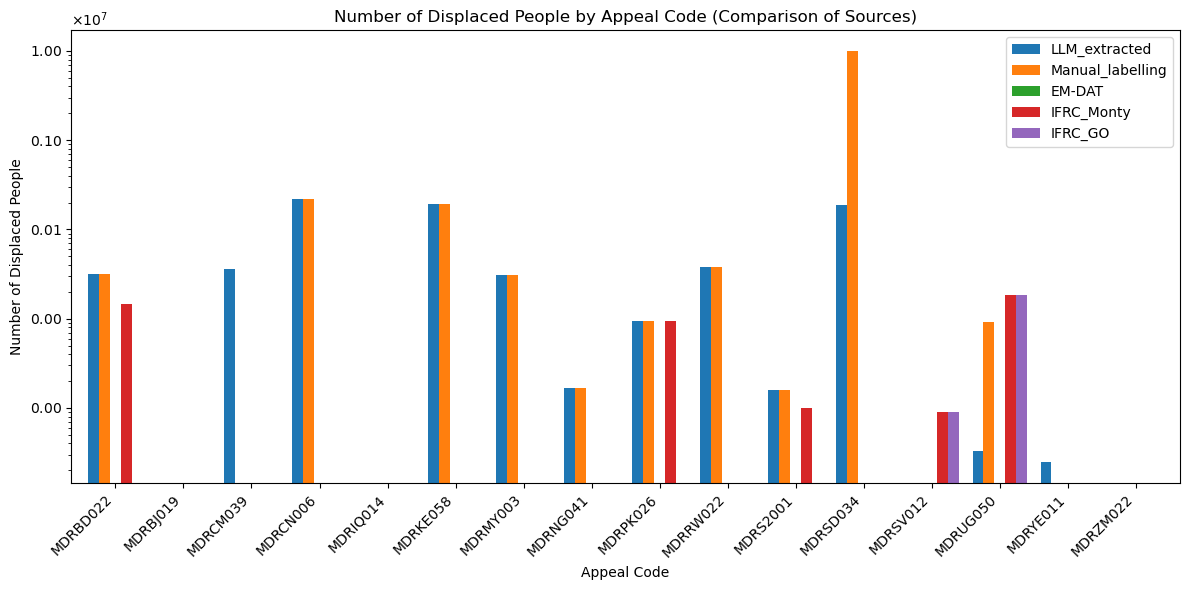

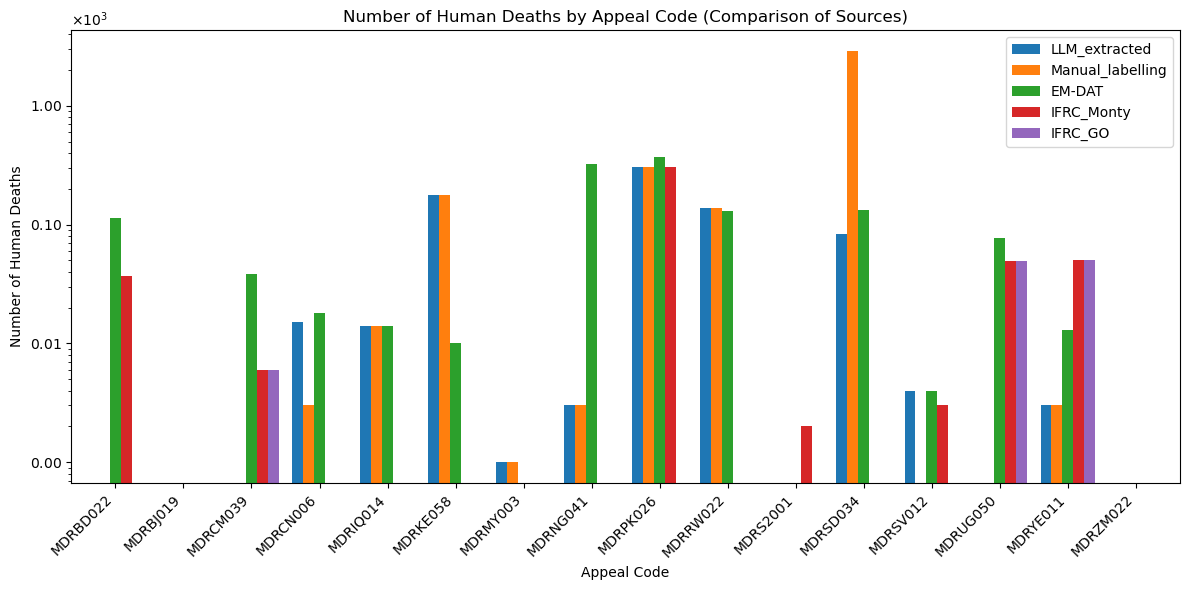

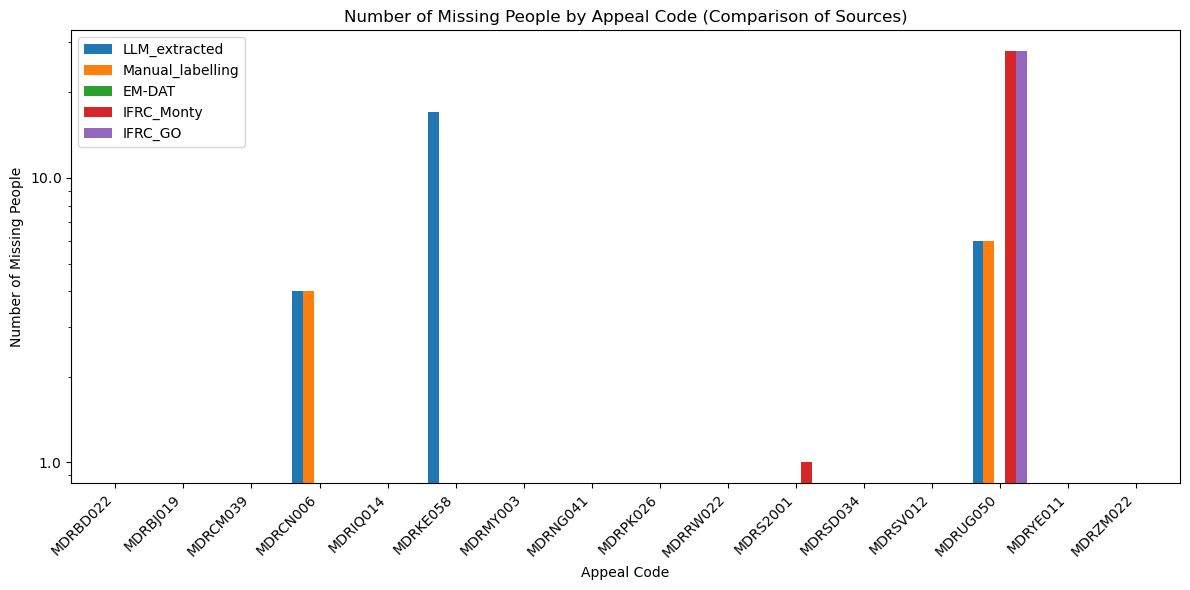

In [59]:
for impactType in list(mapping_impact_type.keys()) :
    df_plot_data = plot_em_dat_comparison(df_llm_geo_grp, df_labelled_geo_grp, df_llm_linked, df_impact_ifrc_monty_appeal, df_go_all, df_llm_geo_grp.appealCode.unique(), impactType, mapping_impact_type)

## Bar plot relative error 

In [ ]:
from matplotlib.ticker import ScalarFormatter

def plot_em_dat_comparison_relative(df_llm_geo_grp, df_labelled_geo_grp, df_emdat_linked, df_impact_ifrc_monty_appeal, df_go, appealCodelist, impactType, mapping_impact_type):
    linthresh=0.1
    margin=1.15

    # --- LLM EXTRACTED (reference baseline) ---
    df1 = (
        df_llm_geo_grp[(df_llm_geo_grp["impactSubtype"] == impactType) &
                       (df_llm_geo_grp["appealCode"].isin(appealCodelist))]
        [["appealCode", "impactValue_final"]]
        .groupby("appealCode", as_index=False)
        .sum()
        .rename(columns={"impactValue_final": "LLM_extracted"})
    )

    # --- MANUALLY LABELLED ---
    df2 = (
        df_labelled_geo_grp[(df_labelled_geo_grp["impactSubtype"] == impactType) &
                            (df_labelled_geo_grp["appealCode"].isin(appealCodelist))]
        [["appealCode", "impactValue_final"]]
        .groupby("appealCode", as_index=False)
        .sum()
        .rename(columns={"impactValue_final": "Manual_labelling"})
    )

    # --- EMDAT MATCHING ---
    emdat_col = mapping_impact_type[impactType]["emdat"]
    if emdat_col is not None:
        df3 = (
            df_emdat_linked.loc[df_emdat_linked["appealCode"].isin(appealCodelist), ["appealCode", emdat_col]]
            .rename(columns={emdat_col: "EM-DAT"})
            .drop_duplicates()
        )
    else:
        df3 = pd.DataFrame({"appealCode": appealCodelist, "EM-DAT": [np.nan]*len(appealCodelist)})

    # --- IFRC MONTY ---
    df4 = (
        df_impact_ifrc_monty_appeal[(df_impact_ifrc_monty_appeal["impact_type"] == mapping_impact_type[impactType]["ifrc_monty"])&
                                    (df_impact_ifrc_monty_appeal["appealCode"].isin(appealCodelist))]
        [["appealCode", "impact_value"]]
        .groupby("appealCode", as_index=False)
        .sum()
        .rename(columns={"impact_value": "IFRC_Monty"})
    )

    # --- IFRC GO ---
    df5 = df_go[["appealCode", mapping_impact_type[impactType]["ifrc_go"]]].loc[df_go["appealCode"].isin(appealCodelist)].rename(
        columns={mapping_impact_type[impactType]["ifrc_go"] : "IFRC_GO"}
    )

    # --- Merge all together ---
    df_all = df1.merge(df2, on="appealCode", how="outer") \
                .merge(df3, on="appealCode", how="outer") \
                .merge(df4, on="appealCode", how="outer") \
                .merge(df5, on="appealCode", how="outer")

    # --- Compute relative error with respect to LLM_extracted ---
    ref = df_all["LLM_extracted"]
    df_rel = df_all.set_index("appealCode").drop(columns=["LLM_extracted"])
    df_rel = (df_rel.sub(ref.values, axis=0)).div(ref.values, axis=0)

    # --- Plot ---
    ax = df_rel.plot(
        kind="bar", figsize=(12, 6), width=0.8
    )

    # --- Symlog y-scale (works for ± values) ---
    ax.set_yscale("symlog", linthresh=linthresh)  # linear near 0, log beyond

    # --- Center around 0 with symmetric limits ---
    max_abs = np.nanmax(np.abs(df_rel.values))
    if not np.isfinite(max_abs) or max_abs == 0:
        max_abs = 1.0
    ymax = max(linthresh, max_abs) * margin
    ax.set_ylim(-ymax, ymax)

    # --- Horizontal lines at each power of 10 (±) within current limits ---
    # compute exponents covered by current limits, but not below linthresh
    lim = ax.get_ylim()
    max_abs_lim = max(abs(lim[0]), abs(lim[1]))
    k_max = int(np.floor(np.log10(max_abs_lim)))
    k_min = int(np.ceil(np.log10(linthresh)))  # start at boundary of log region
    if k_max >= k_min:
        for k in range(k_min, k_max + 1):
            val = 10.0 ** k
            ax.axhline(val,  color="gray", linestyle="--", linewidth=0.8, alpha=0.7, zorder=0)
            ax.axhline(-val, color="gray", linestyle="--", linewidth=0.8, alpha=0.7, zorder=0)

    # Zero line
    ax.axhline(0, color="black", linewidth=1, zorder=1)

    plt.axhline(0, color="black", linewidth=1)
    plt.title(f"Relative Error vs LLM-extracted for {impactType}")
    plt.xlabel("Appeal Code")
    plt.ylabel("Relative Error (vs LLM-extracted)")

    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    return df_rel.reset_index()


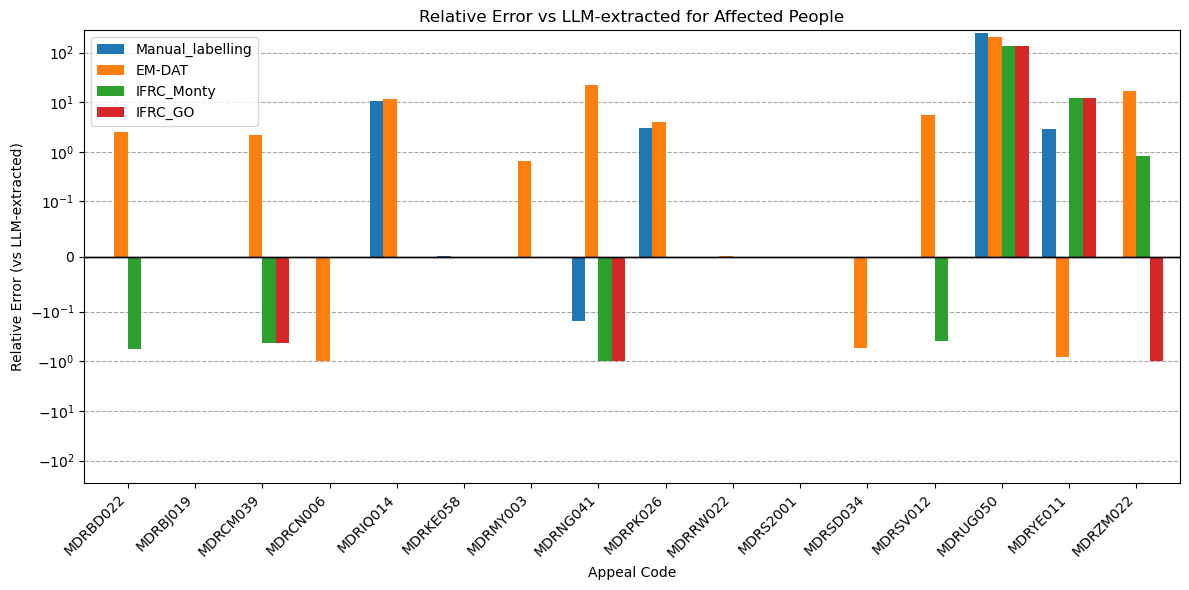

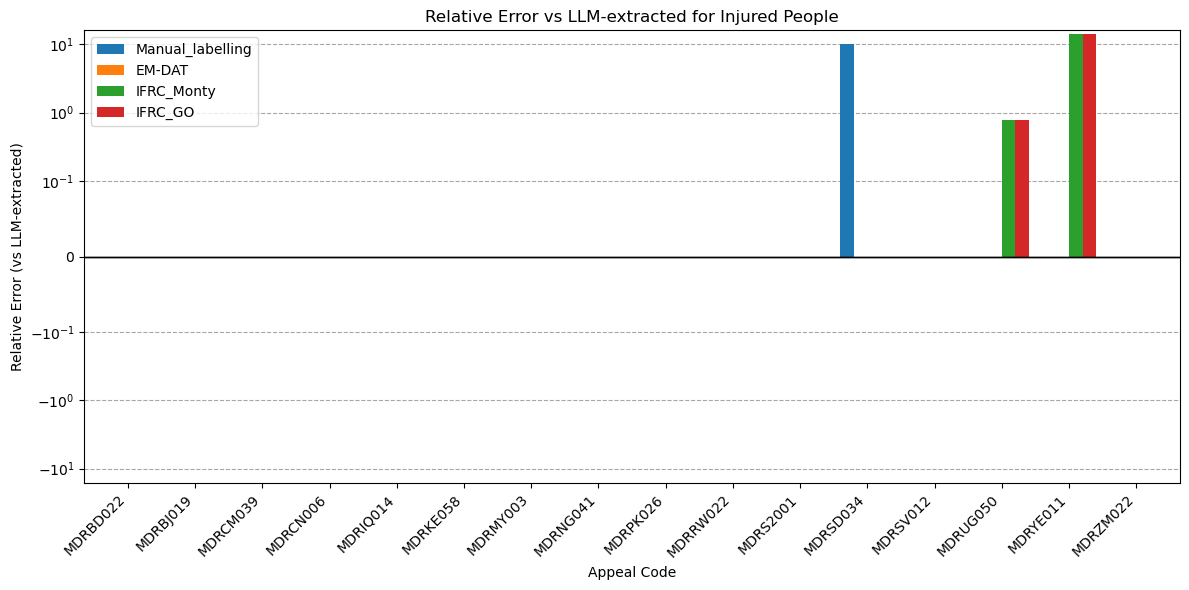

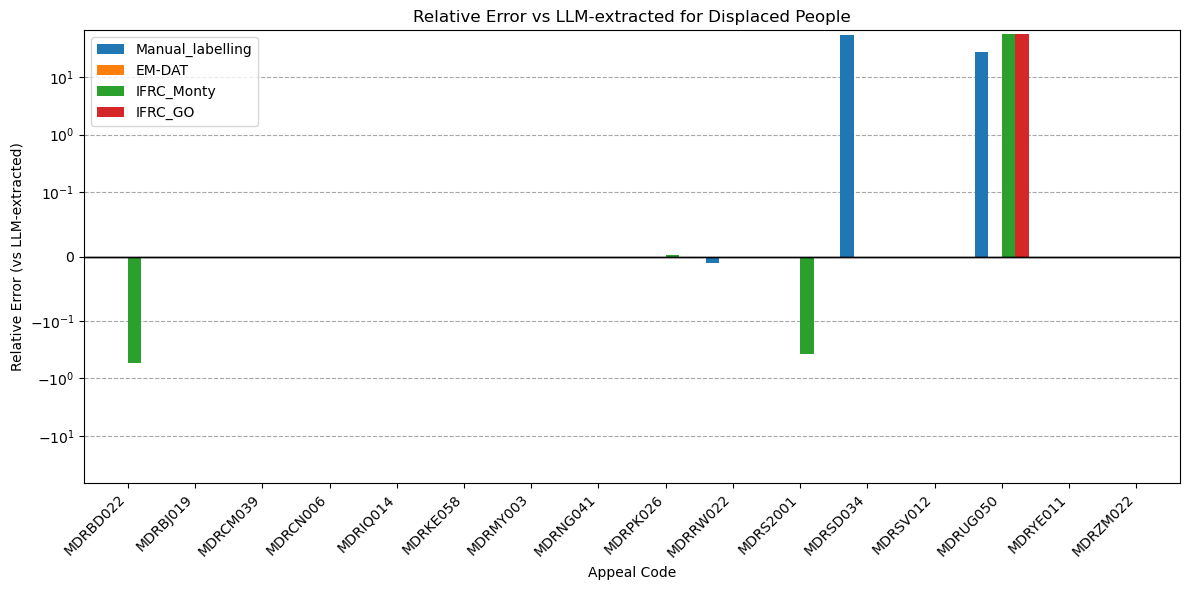

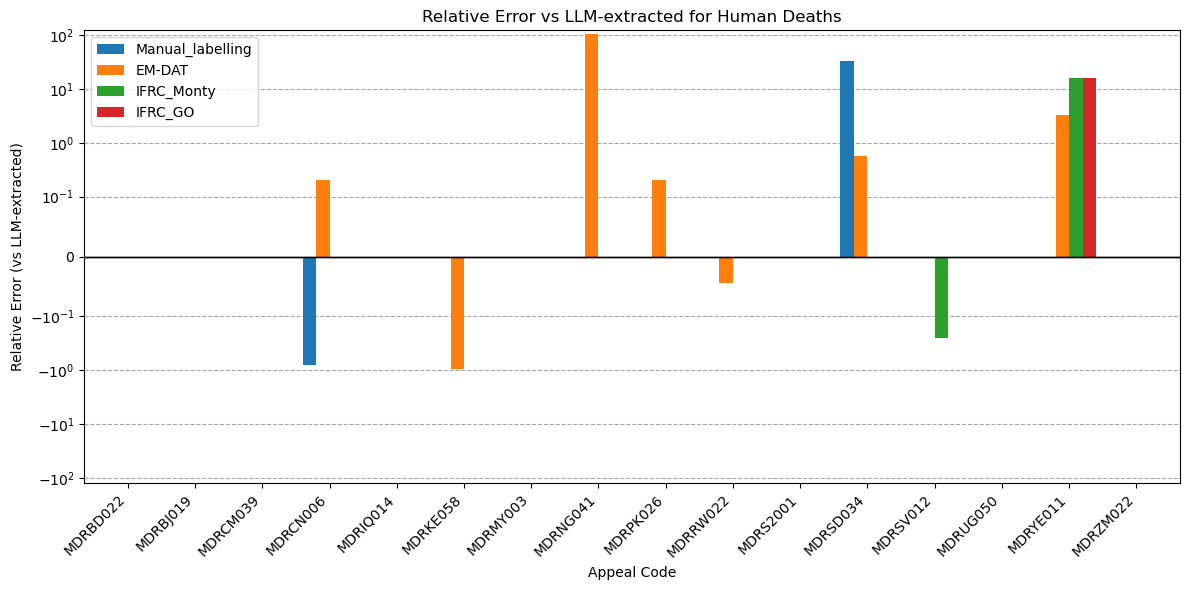

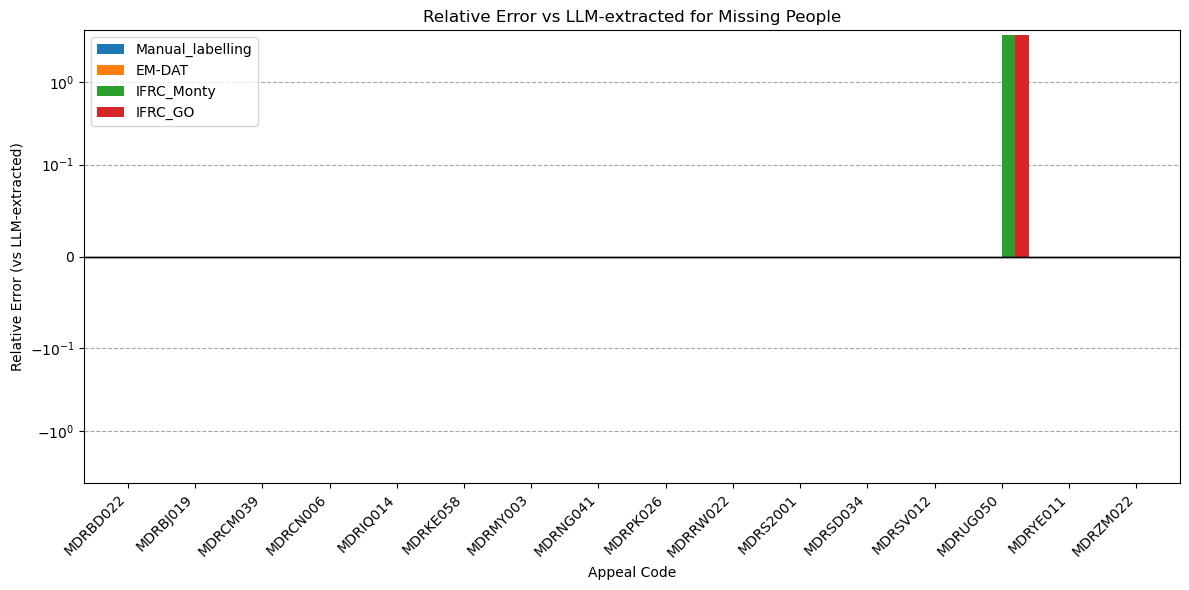

In [68]:
for impactType in list(mapping_impact_type.keys()) :
    df_plot_data = plot_em_dat_comparison_relative(df_llm_geo_grp, df_labelled_geo_grp, df_llm_linked, df_impact_ifrc_monty_appeal, df_go_all, df_llm_geo_grp.appealCode.unique(), impactType, mapping_impact_type)